# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform an exploratory analysis of the historical cryptocurrency market data collected during the data acquisition stage.

This analysis aims to understand the structure, quality, and behavior of the dataset before any feature engineering or machine learning techniques are applied.

The notebook focuses on:

- Examining dataset dimensions and structure
- Assessing data quality and completeness
- Analyzing price behavior over time
- Exploring trading volume dynamics
- Investigating return characteristics and distributions
- Identifying patterns that may be useful for market regime detection

The insights obtained from this analysis will guide the feature engineering process and support the development of the market regime detection framework.

------

## Project Configuration

This section loads the project configuration and paths required to access the datasets generated during the data collection stage.

Using a centralized configuration file ensures consistency and reproducibility across all notebooks in the project pipeline.

In [ ]:
# ==========================================
# Libraries and routs for the config.py
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
%matplotlib inline

# Absoulte Path To The Project Root
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)
    
from config import ASSETS, INTERVAL, RAW_DATA_PATH, PROCESSED_DATA_PATH

------

## Load Dataset

In this section, the processed market dataset generated during the data collection stage is loaded into memory.

The dataset contains historical OHLCV (Open, High, Low, Close, Volume) information and serves as the foundation for the exploratory analysis performed in this notebook.

In [ ]:
# ==========================================
# Load Dataset
# ==========================================

if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)
file_path = f"{RAW_DATA_PATH}/{asset_name}_{INTERVAL}_raw.csv"

df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [ ]:
# ==========================================
# Display Dataset Information
# ==========================================
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


In [ ]:
# ==========================================
# Display Basic Information
# ==========================================
df.info()
df.columns

<class 'pandas.DataFrame'>
DatetimeIndex: 3095 entries, 2018-01-01 to 2026-06-22
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3095 non-null   float64
 1   High    3095 non-null   float64
 2   Low     3095 non-null   float64
 3   Open    3095 non-null   float64
 4   Volume  3095 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 145.1 KB


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

-------

## Dataset Overview

Before performing any exploratory analysis, it is important to understand the basic structure of the dataset.

This section examines:

- Dataset dimensions
- Available variables
- Data types
- Index structure

These checks help verify that the dataset was loaded correctly and is suitable for further analysis.

In [ ]:
# ==========================================
# Dataset Dimensions
# ==========================================
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3095
Columns: 5


### Dataset Dimensions Interpretation

The dataset contains 3,081 observations and 6 financial variables, providing a substantial historical record of market activity across multiple market conditions.

The number of observations is sufficient for exploratory analysis, feature engineering, dimensionality reduction, and clustering techniques that will be applied in later stages of the project.

Additionally, the dataset includes both price-related variables and trading volume information, providing a solid foundation for identifying different market regimes.

In [ ]:
# ==========================================
# Data Type Analysis
# ==========================================
df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [ ]:
# ==========================================
# Display Index For Better Understanding
# ==========================================
print(type(df.index))
print(df.index[:5])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05'],
              dtype='datetime64[us]', name='Date', freq=None)


### Data Type Interpretation

All financial variables were loaded using appropriate numerical data types.

Price-related variables (Open, High, Low, Close, and Adjusted Close) are stored as float64 values, allowing for precise numerical calculations. Trading volume is stored as int64, which is appropriate because volume represents discrete transaction counts.

The Date variable is not displayed among the columns because it has been converted into a DatetimeIndex. This is the preferred structure for time-series analysis and will facilitate subsequent calculations, visualizations, and feature engineering tasks.

-----

## Data Quality Assessment

Data quality verification is a critical step before any statistical analysis or machine learning workflow.

This section evaluates:

- Missing values
- Dataset completeness
- Structural consistency

Ensuring data integrity at this stage helps prevent issues during feature engineering, dimensionality reduction, and clustering.

In [ ]:
# ==========================================
# Missing Values Analysis 
# ==========================================
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### Missing Values Interpretation

The missing values analysis shows that no variables contain null observations.

This indicates that the dataset is complete and no imputation, interpolation, or row removal procedures are required before continuing with the analysis.

Having a complete dataset is particularly important for time-series modeling because missing observations can distort return calculations, rolling statistics, and clustering results. Therefore, the dataset is considered ready for the next stages of exploratory analysis and feature engineering.

------ 

## Price Behavior Analysis

In this section, we aim to answer the following questions in order to better understand the historical behavior of the selected asset:

- How has the selected asset evolved since 2018?
- Are there distinct market phases?
- Are there periods of unusually high growth or decline?

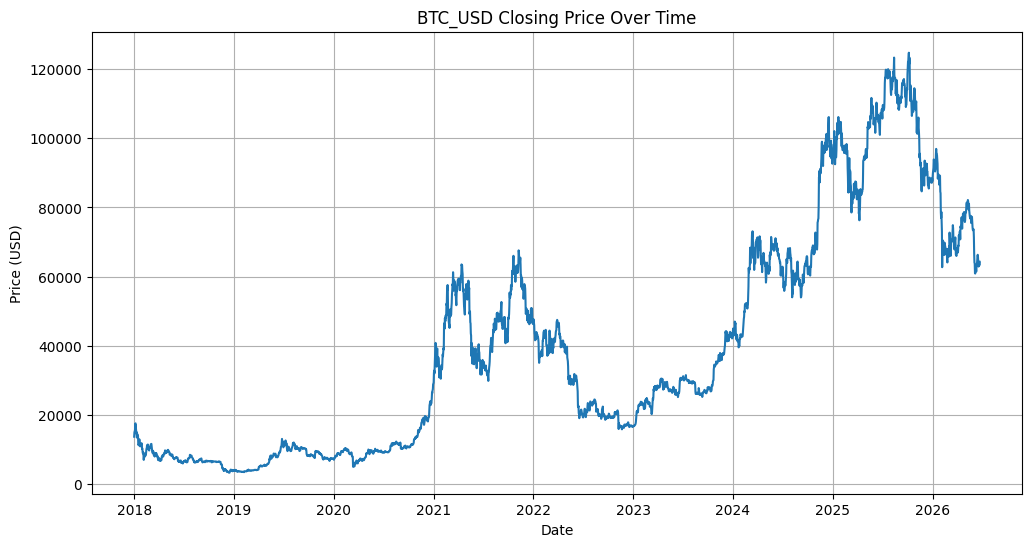

In [ ]:
# ==========================================
# Price Behaivor Chart
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"])

plt.title(f"{asset_name.upper()} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid(True)

## Interpretation of this chart
### Multiple Distinct Market Phases

The most important observation for this project is that the selected asset does not exhibit a single consistent behavior throughout the observation period.

We can visually identify several phases:

#### Phase 1: Low-Price Consolidation (2018–2020)
- Prices remain relatively low compared to later years.
- Volatility exists but is comparatively moderate.
- The market appears relatively stable.

This could later correspond to a low-volatility regime.

#### Phase 2: Explosive Bull Market (2020–2021)
- Strong upward trend.
- Rapid appreciation in a short period.
- Increasing price fluctuations.

This period would likely exhibit:

- High positive returns
- Strong momentum
- Elevated volatility

Potentially a bull regime.

#### Phase 3: Bear Market and Correction (2021–2022)
- Sharp decline from the previous highs.
- Sustained downward movement.
- Large fluctuations during the decline.

This could form a distinct bear regime.

#### Phase 4: Recovery and Transition (2023–2024)
- Price gradually recovers.
- Upward trend becomes more persistent.
- Volatility appears lower than during the crash.

This could represent a recovery regime.

#### Phase 5: Strong Expansion (2024–2025)
- Another powerful bullish period.
- New all-time highs.
- Significant volatility remains present.

Likely another bullish/high-growth regime.

#### Phase 6: Correction and Instability (2025–2026)
- Noticeable decline after the peak.
- Large swings continue.
- Market direction becomes less clear.

Potentially a transition or correction regime.

#### Summary

The Bitcoin price series exhibits substantial variability over time, characterized by alternating periods of growth, decline, recovery, and consolidation.

Several distinct market phases can be visually identified throughout the observation period. These phases differ not only in price level but also in trend strength and apparent volatility. Major bullish cycles are followed by significant corrections, suggesting that market behavior changes considerably over time.

The existence of these visually distinguishable periods provides preliminary evidence that Bitcoin may operate under multiple market regimes rather than a single, stationary process.

This observation supports the use of feature engineering, dimensionality reduction, and clustering techniques in later stages of the project, as different periods appear to exhibit unique combinations of return, momentum, and volatility characteristics.

----- 

## Volume Behavior Analysis

Price movements alone do not fully describe market behavior. Trading volume provides information about market participation and can help identify periods of increased investor activity, speculation, accumulation, or panic selling.

In this section, we analyze the trading volume of the selected asset over time to answer the following questions:

- How has trading activity evolved since 2018?
- Are there periods of unusually high market participation?
- Do volume spikes coincide with major market events?
- Can volume help explain potential market regimes?

Understanding volume behavior is important because market regimes are often characterized not only by differences in price trends but also by differences in trading activity.

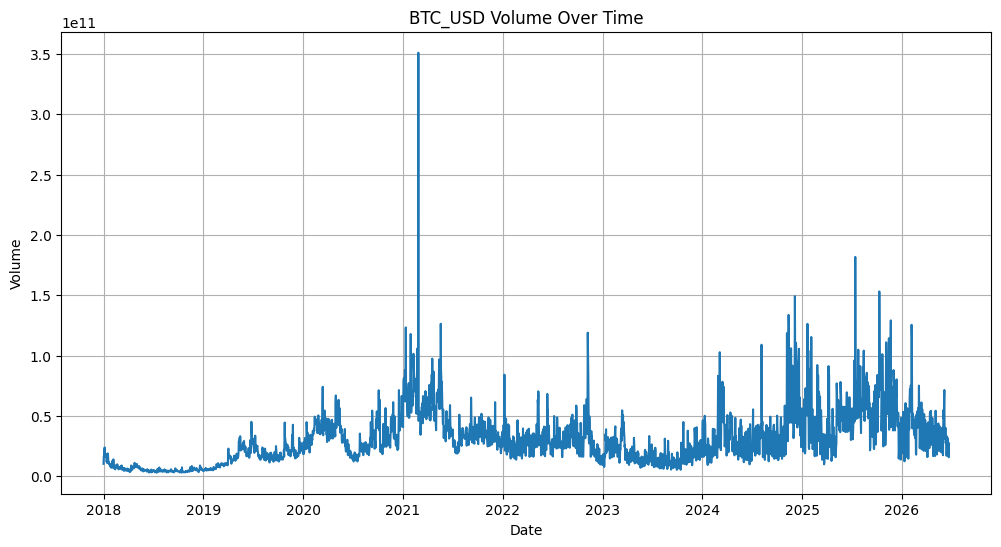

In [ ]:
# ==========================================
# Volume Behavior Chart
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Volume"])

plt.title(f"{asset_name.upper()} Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

### Interpretation

The trading volume series reveals substantial changes in market participation throughout the observation period.

Trading activity remains relatively low during the early years of the dataset, particularly between 2018 and 2020. Beginning in 2020, volume increases considerably and several large spikes emerge, indicating periods of heightened market interest and trading activity.

A particularly notable feature is the extreme volume spike observed around 2021, suggesting an episode of exceptional market participation. Following this period, trading activity remains elevated compared to earlier years, indicating that the market structure may have evolved over time.

The volume behavior observed in the chart complements the findings from the price analysis. Periods of strong price movements are often accompanied by increased trading activity, providing additional evidence that the asset exhibits multiple market states characterized by different levels of participation, trend behavior, and volatility.

These observations further support the use of clustering techniques for identifying distinct market regimes in later stages of the project.

----- 

### 30-Day Rolling Average Volume

The daily trading volume chart provides valuable information about market activity; however, it is heavily influenced by short-term fluctuations and isolated volume spikes. These abrupt changes can make it difficult to identify broader trends in market participation.

To better understand the underlying behavior of trading activity, a 30-day rolling average is calculated. This technique smooths short-term fluctuations by averaging the trading volume over the previous 30 days.

The objective of this visualization is not to eliminate important market events, but rather to highlight long-term changes in participation levels and identify periods where market activity systematically increases or decreases.

By examining the smoothed volume series, we can more easily detect structural changes in market behavior that may correspond to different market regimes.

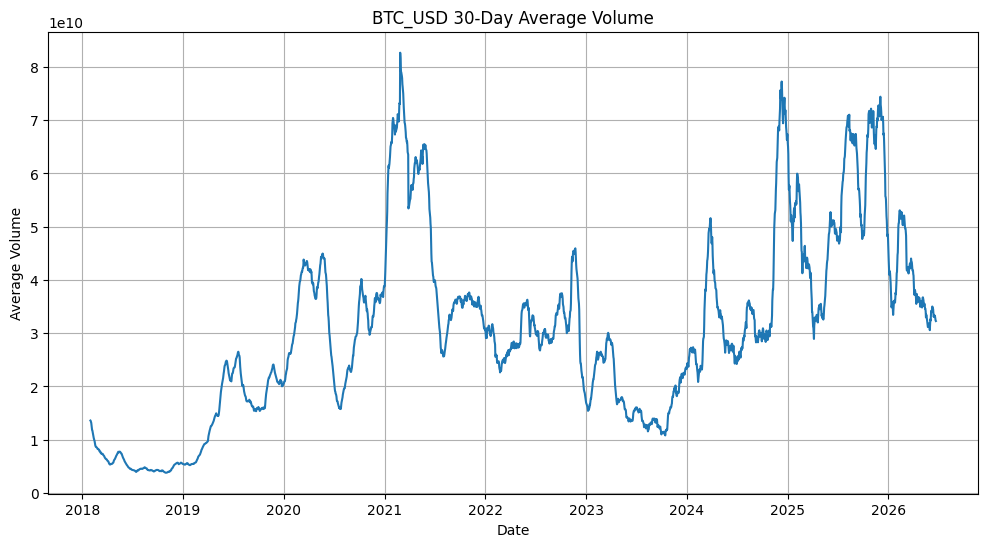

In [ ]:
# ==========================================
# Rolling Average Volume Chart
# ==========================================
df["Volume_MA30"] = df["Volume"].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Volume_MA30"])

plt.title(f"{asset_name.upper()} 30-Day Average Volume")
plt.xlabel("Date")
plt.ylabel("Average Volume")

plt.grid(True)


### Interpretation

The 30-day rolling average volume reveals several long-term changes in market participation that were less visible in the daily volume chart.

From 2018 to early 2020, average trading activity remained relatively low and stable, indicating a period of comparatively limited market participation. Beginning in 2020, average volume increased substantially and remained elevated for extended periods, coinciding with the strong bullish market observed in the price analysis.

A major increase in average trading volume can be observed during 2021, suggesting a prolonged period of intense market activity rather than a single isolated event. Although trading activity declined after this period, it did not return to the levels observed during the early years of the dataset, indicating a structural change in market participation.

Additional periods of elevated average volume are visible during 2024 and 2025, corresponding to another phase of strong market movement. These sustained increases suggest that market activity tends to intensify during periods of significant price appreciation and uncertainty.

Compared with the raw volume chart, the rolling average highlights the underlying trend in market participation and provides clearer evidence that Bitcoin experiences distinct periods characterized by different levels of trading activity.

These findings further support the hypothesis that the market operates under multiple regimes, where participation, volatility, and price behavior vary substantially over time.

----- 

## Return Analysis

While price levels provide information about the long-term evolution of the selected asset, they do not directly describe the magnitude and direction of daily market movements.

For financial analysis, returns are often more informative than raw prices because they measure relative changes from one period to the next. Returns allow us to compare market behavior across different price levels and identify periods of growth, decline, and instability.

In the context of market regime detection, returns are particularly important because they form the basis for many financial indicators, including volatility and momentum, which will later be used for clustering analysis.

The objective of this section is to examine how Bitcoin returns behave over time and determine whether different periods exhibit distinct return characteristics.

In [ ]:
# ==========================================
# Calculate Daily Returns
# ==========================================
df["Returns"] = df["Close"].pct_change()

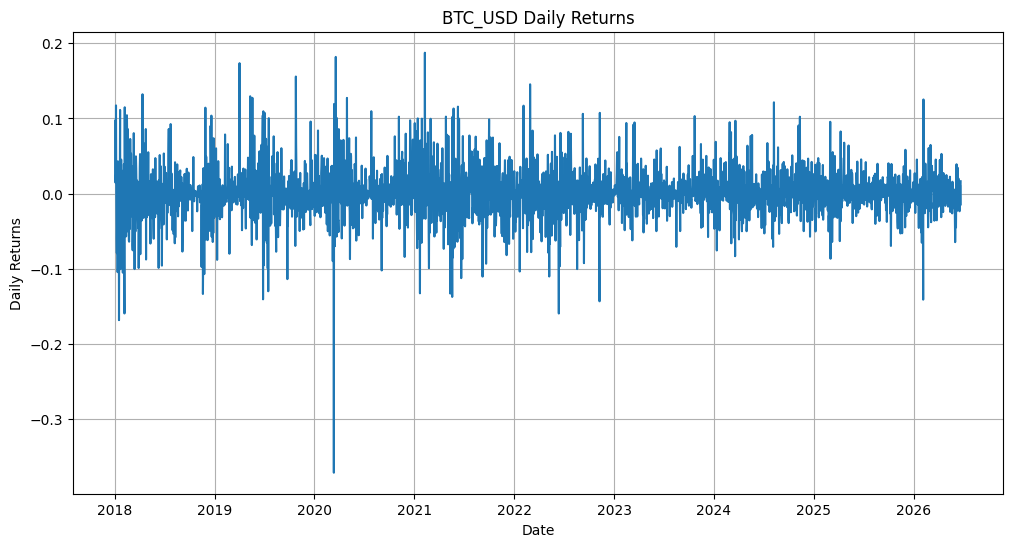

In [14]:
# Visualize returns through time
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Returns"])

plt.title(f"{asset_name.upper()} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Returns")

plt.grid(True)

### Interpretation

The daily return series fluctuates around zero throughout the observation period, indicating that positive and negative daily movements occur regularly over time.

Although the average return appears relatively stable, the magnitude of fluctuations varies considerably across different periods. Some intervals exhibit relatively small daily changes, while others contain frequent large positive and negative movements.

Periods of elevated return variability are particularly visible around 2020–2022, suggesting that market uncertainty and volatility increased substantially during these years. Importantly, large return movements tend to occur in clusters rather than as isolated events, indicating that periods of high volatility are often followed by additional high-volatility observations.

These findings suggest that Bitcoin does not exhibit constant market behavior over time. Instead, the return series appears to transition between periods of lower and higher volatility, providing further evidence for the existence of distinct market regimes.

The presence of volatility clustering is particularly relevant for this project because volatility is expected to be one of the primary characteristics used to differentiate market regimes during the clustering stage.

-------

## Return Distribution Analysis

While the previous visualization showed how returns evolve through time, it does not reveal how returns are distributed overall.

Analyzing the distribution of returns helps identify common market behavior, the frequency of extreme events, and whether returns follow a normal distribution. Understanding these characteristics is important because many financial models assume normally distributed returns, while real financial markets often exhibit asymmetry and heavy tails.

The objective of this section is to examine the statistical distribution of daily asset returns and evaluate the presence of extreme observations that could influence market regime detection.

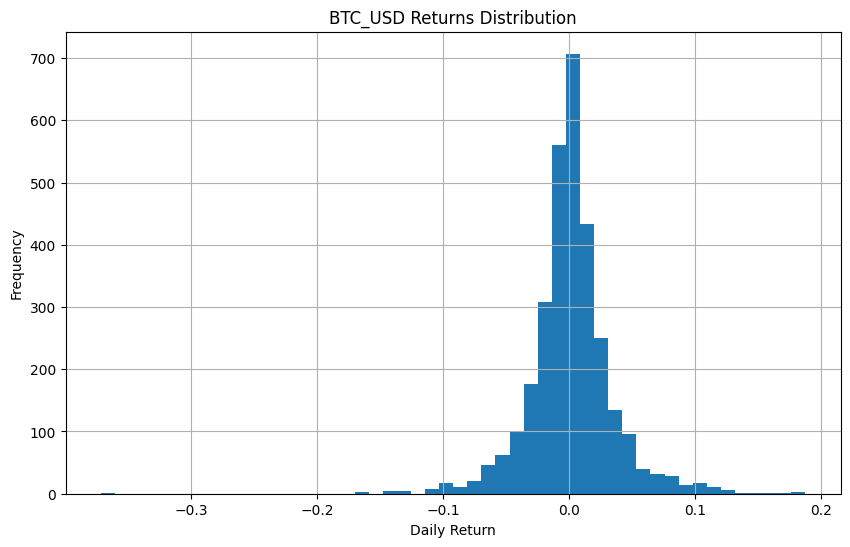

: 

In [ ]:
# Return distribution visualization
plt.figure(figsize=(10,6))

plt.hist(
    df["Returns"].dropna(),
    bins=50
)

plt.title(f"{asset_name.upper()} Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

### Interpretation

The return distribution is heavily concentrated around zero, indicating that most daily asset price changes are relatively small. This behavior is typical of financial return series, where modest day-to-day fluctuations occur more frequently than large movements.

The distribution appears approximately symmetric around zero; however, the negative tail extends slightly farther than the positive tail, suggesting that extreme negative returns may be more severe than extreme positive returns.

Although the majority of observations remain close to zero, the histogram exhibits long tails on both sides. These tails indicate the presence of rare but substantial positive and negative price movements. Consequently, asset returns do not appear to follow a perfect normal distribution.

The combination of a sharp central peak and heavy tails suggests that extreme market events occur more frequently than would be expected under a Gaussian assumption. This characteristic is commonly observed in financial markets and reflects the presence of significant tail risk.

These findings provide additional evidence that Bitcoin experiences periods of varying market conditions and risk levels. The existence of both frequent small returns and occasional extreme movements supports the hypothesis that distinct market regimes may be present within the dataset.

------

# Conclusion

The exploratory analysis confirms that the dataset is suitable for quantitative market analysis.

Key findings include:

- Complete and consistent historical records
- No significant data quality issues
- Observable changes in price and volume dynamics
- Volatility clustering and non-normal return behavior

These observations provide valuable insight into market structure and establish a strong foundation for the next stage of the project: feature engineering and dimensionality reduction.